# Streaming codec decode demo (`streaming_codec_decode.py`)

This notebook tests **chunked / overlap-save** decoding of EasyMagpieTTS codec
codes against a **full one-shot** decode, using the causal `25fps spectral codec`.

**Streaming schedule requested:** `left_context = 24` past frames + `chunk_frames = 3`
new ("effective") frames per step = a **27-frame** decode window that shifts
forward 3 frames at a time. Because the decoder is causal, `right_context = 0`
(no lookahead).

We then:
1. Decode the **entire** code sequence in one shot.
2. Decode it **incrementally** (3 frames / step), concatenating emitted audio.
3. **Plot** both waveforms + their difference.
4. **Listen** to both.

Provide your codes as a torch file (`torch.save(codes, "codes.pt")`) with shape
`(C, T)` or `(B, C, T)` in the model's codebook space (i.e. the same space as
`StreamingFinalizeOutput.audio_codes`).

In [1]:
import os
import sys

import numpy as np
import torch

# ----------------------------------------------------------------------------
# CONFIG -- edit these paths.
# ----------------------------------------------------------------------------
# Directory containing streaming_codec_decode.py (this notebook's folder).
SCRIPT_DIR = os.path.abspath(".")

# Checkpoints.
NEMO_FILE = "/home/vklimkov/workspace/emp/ckpt/easymagpietts_NEXT/2605_NemotronTTS_V0.2/v2/2605_EMTTS_SmallMamba_Step150k_posttrained_epoch12.nemo"  # <-- set me
CODEC_MODEL_PATH = "/home/vklimkov/workspace/emp/ckpt/easymagpietts_NEXT/25fps_spectral_codec_with_bandwidth_extension.nemo"
PHONEME_TOKENIZER_PATH = "/home/vklimkov/workspace/emp/ckpt/easymagpietts_NEXT/2605_NemotronTTS_V0.2/bpe_ipa_tokenizer_2048_en_de_es_fr_hi_it_vi_zh_ko-KR_pt-BR_ar.json"  # optional override; set if the path baked in the .nemo is missing
DISABLE_CAS_FOR_CONTEXT_TEXT = False  # set True for legacy Qwen EasyMagpie checkpoints

# Codes to decode (torch.save'd tensor or dict). Shape (C, T) or (B, C, T).
CODES_PATH = "/home/vklimkov/workspace/emp/NeMo/examples/tts/easymagpie_vllm_omni/codes.pt"  # <-- set me

# Streaming schedule: 24 left-context + 3 effective frames/step (= 27-frame window), R=0.
LEFT_CONTEXT = 24
CHUNK_FRAMES = 3
RIGHT_CONTEXT = 0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

sys.path.insert(0, SCRIPT_DIR)
from streaming_codec_decode import (  # noqa: E402
    StreamingCodecDecoder,
    StreamingDecodeConfig,
    chunked_decode,
    make_nemo_decode_fn,
)

print("device:", DEVICE)

device: cuda


## 1. Load the model + codec

`load_easy_magpie_model` restores the decoder-only model **and** the codec, sets
up the optional index-converter and frame-unstacking, and gives us
`model._codec_helper` used by `make_nemo_decode_fn`.

In [2]:
from nemo.collections.tts.modules.magpietts_inference.utils import ModelLoadConfig, load_easy_magpie_model

model, ckpt_name = load_easy_magpie_model(
    ModelLoadConfig(
        nemo_file=NEMO_FILE,
        codecmodel_path=CODEC_MODEL_PATH,
        phoneme_tokenizer_path=PHONEME_TOKENIZER_PATH,
        disable_cas_for_context_text=DISABLE_CAS_FOR_CONTEXT_TEXT,
    ),
    device=DEVICE,
)
model.eval()

SR = int(model.output_sample_rate)
decoder = model._codec_model.audio_decoder
print("checkpoint:", ckpt_name)
print("output_sample_rate:", SR)
print("decoder:", type(decoder).__name__, "| is_causal:", getattr(decoder, "is_causal", None))
print("num_audio_codebooks (model space):", model.num_audio_codebooks)
print("frame_stacking_factor:", model.frame_stacking_factor)
print("codec native num_codebooks:", model._codec_model.num_codebooks)

/home/vklimkov/miniconda3/envs/emp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
OneLogger: Setting error_handling_strategy to DISABLE_QUIETLY_AND_REPORT_METRIC_ERROR for rank (rank=0) with OneLogger disabled. To override: explicitly set error_handling_strategy parameter.
No exporters were provided. This means that no telemetry data will be collected.
[NeMo W 2026-06-04 17:19:53 evaluate_generated_audio:48] UTMOSv2Calculator not available: UTMOSv2 is not installed. Please install it using `pip install git+https://github.com/sarulab-speech/UTMOSv2.git@v1.2.1`.. UTMOSv2 metrics will be disabled. Install required dependencies to enable.To install utmosv2 run `pip install git+https://github.com/sarulab-speech/UTMOSv2.git@v1.2.1`.


[NeMo I 2026-06-04 17:19:53 utils:452] Loading model from NeMo archive: /home/vklimkov/workspace/emp/ckpt/easymagpietts_NEXT/2605_NemotronTTS_V0.2/v2/2605_EMTTS_SmallMamba_Step150k_posttrained_epoch12.nemo


[NeMo W 2026-06-04 17:19:55 modelPT:176] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    dataset:
      dataset_type: tarred_vocoder
      dataset_args:
        dataset_meta:
          libritts:
            manifest_path: /lustre/fsw/portfolios/llmservice/projects/llmservice_nemo_speechlm/data/TTS/libritts_audio/22khz/tarred_audio/train_manifest.json
            tar_filepath: /lustre/fsw/portfolios/llmservice/projects/llmservice_nemo_speechlm/data/TTS/libritts_audio/22khz/tarred_audio/audio_{0..44}.tar
          librittsr:
            manifest_path: /lustre/fsw/portfolios/llmservice/projects/llmservice_nemo_speechlm/data/TTS/libritts_r_audio/22khz/tarred_audio/train_manifest.json
            tar_filepath: /lustre/fsw/portfolios/llmservice/projects/llmservice_nemo_speechlm/data/TTS/libritts_r_audio/22khz/tarred_audio/audio_{0..49}.tar
         

[NeMo I 2026-06-04 17:19:55 audio_codec:109] Vector quantizer does not support commit loss.


Loading weights: 100%|██████████| 248/248 [00:00<00:00, 30449.56it/s]


[NeMo I 2026-06-04 17:19:57 save_restore_connector:286] Model AudioCodecModel was successfully restored from /home/vklimkov/workspace/emp/ckpt/easymagpietts_NEXT/25fps_spectral_codec_with_bandwidth_extension.nemo.
[NeMo I 2026-06-04 17:19:57 easy_magpietts_inference:317] Multi-mode training with 1 modes:
[NeMo I 2026-06-04 17:19:57 easy_magpietts_inference:319]   - streaming_3_5: text_input_mode=streaming, streaming_phonemes_delay=3, streaming_speech_delay=5
[NeMo I 2026-06-04 17:19:59 easy_magpietts_inference:436] Using decoder type: nemotron_h
[NeMo I 2026-06-04 17:20:06 easy_magpietts_inference:477] NemotronH config: 31 layers, pattern=MEMEM*EMEMEM*EMEMEME...
[NeMo I 2026-06-04 17:20:06 easy_magpietts_inference:504] Single training mode 'streaming_3_5', skipping task embedding
[NeMo I 2026-06-04 17:20:06 easy_magpietts_inference:542] Local transformer type: autoregressive
[NeMo I 2026-06-04 17:20:08 save_restore_connector:286] Model EasyMagpieTTSInferenceModel was successfully resto

## 2. Load the codes

Robustly coerce whatever you saved into a `(1, C, T)` long tensor. If your codes
are arranged `(T, C)` instead of `(C, T)`, flip `ASSUME_TIME_LAST` below.

In [3]:
ASSUME_TIME_LAST = True  # codes are (..., C, T); set False if they are (..., T, C)

raw = torch.load(CODES_PATH, map_location="cpu")
if isinstance(raw, dict):
    for k in ("codes", "audio_codes", "predicted_codes", "tokens"):
        if k in raw:
            print(f"using dict key {k!r}")
            raw = raw[k]
            break
    else:
        raise KeyError(f"none of codes/audio_codes/predicted_codes/tokens in {list(raw.keys())}")

codes = raw if torch.is_tensor(raw) else torch.as_tensor(raw)
if codes.dim() == 2:
    codes = codes.unsqueeze(0)  # (C, T) -> (1, C, T)
assert codes.dim() == 3, f"expected (B, C, T), got {tuple(codes.shape)}"
if not ASSUME_TIME_LAST:
    codes = codes.transpose(1, 2).contiguous()  # (B, T, C) -> (B, C, T)

# Keep a single utterance for the demo.
codes = codes[:1].long().to(DEVICE)
n_frames = codes.shape[-1]
codes_len = torch.tensor([n_frames], dtype=torch.long, device=DEVICE)

print("codes:", tuple(codes.shape), codes.dtype, "| frames:", n_frames)
print(f"duration @25fps: {n_frames / 25:.2f}s  | code value range: [{int(codes.min())}, {int(codes.max())}]")

codes: (1, 8, 148) torch.int64 | frames: 148
duration @25fps: 5.92s  | code value range: [0, 1021]


## 3. Full one-shot decode (reference)

`make_nemo_decode_fn` reproduces exactly what `streaming_finalize` does:
optional frame-unstack -> optional index-converter -> `codec.decode`.

In [4]:
decode_fn = make_nemo_decode_fn(model)

with torch.inference_mode():
    full_audio, full_len = decode_fn(codes, codes_len)

full_wav = full_audio[0, : int(full_len[0])].float().cpu().numpy()
print("full decode:", full_wav.shape, "samples  |", f"{full_wav.shape[0] / SR:.2f}s")
print("inferred output samples/frame:", full_wav.shape[0] // n_frames)

full decode: (130536,) samples  | 5.92s
inferred output samples/frame: 882


## 4. Streaming decode: 24 context + 3 frames/step, shifting forward

We feed the codes **3 frames at a time** (simulating the AR model emitting frames
as it goes). The `StreamingCodecDecoder` buffers them and, for each new 3-frame
body, decodes a `[<=24 left context | 3 body]` window and keeps only the 3-frame
body audio. `flush()` drains the final partial chunk.

In [5]:
# IMPORTANT: set samples_per_frame explicitly. The codec helper zero-pads windows
# shorter than 4 frames, so inferring spf from the first (3-frame) window would be
# wrong and truncate the stream. Take the exact value from the full decode.
SPF = int(full_len[0]) // n_frames
cfg = StreamingDecodeConfig(
    chunk_frames=CHUNK_FRAMES,
    left_context=LEFT_CONTEXT,
    right_context=RIGHT_CONTEXT,
    samples_per_frame=SPF,
)
print("samples_per_frame:", SPF)
print("streaming config:", cfg, "| decode window =", cfg.left_context + cfg.chunk_frames, "frames")

dec = StreamingCodecDecoder(decode_fn, cfg)

emitted_pieces = []
step_log = []
with torch.inference_mode():
    for start in range(0, n_frames, CHUNK_FRAMES):
        new_frames = codes[:, :, start : start + CHUNK_FRAMES]  # (1, C, <=3)
        out = dec.push(new_frames)  # (1, T_emit)
        if out.shape[-1] > 0:
            emitted_pieces.append(out)
        step_log.append((start, new_frames.shape[-1], out.shape[-1]))
    tail = dec.flush()
    if tail.shape[-1] > 0:
        emitted_pieces.append(tail)

stream_audio = torch.cat(emitted_pieces, dim=-1)
stream_wav = stream_audio[0].float().cpu().numpy()
print(f"pushed {len(step_log)} steps of {CHUNK_FRAMES} frames; tail flush = {tail.shape[-1]} samples")
print("streaming decode:", stream_wav.shape, "samples  |", f"{stream_wav.shape[0] / SR:.2f}s")

streaming config: StreamingDecodeConfig(chunk_frames=3, left_context=24, right_context=0, samples_per_frame=None) | decode window = 27 frames
pushed 50 steps of 3 frames; tail flush = 0 samples
streaming decode: (6174,) samples  | 0.28s


## 5. Compare: waveforms + difference

For a causal decoder with `left_context` >= receptive field, streaming should
match the one-shot decode to within float tolerance. We align lengths, report the
max/RMS difference, and plot both overlaid plus the error.

length: full=130536  stream=6174  (compared first 6174)
max |diff| = 2.185e-03   RMS diff = 2.128e-04
signal RMS = 9.284e-04


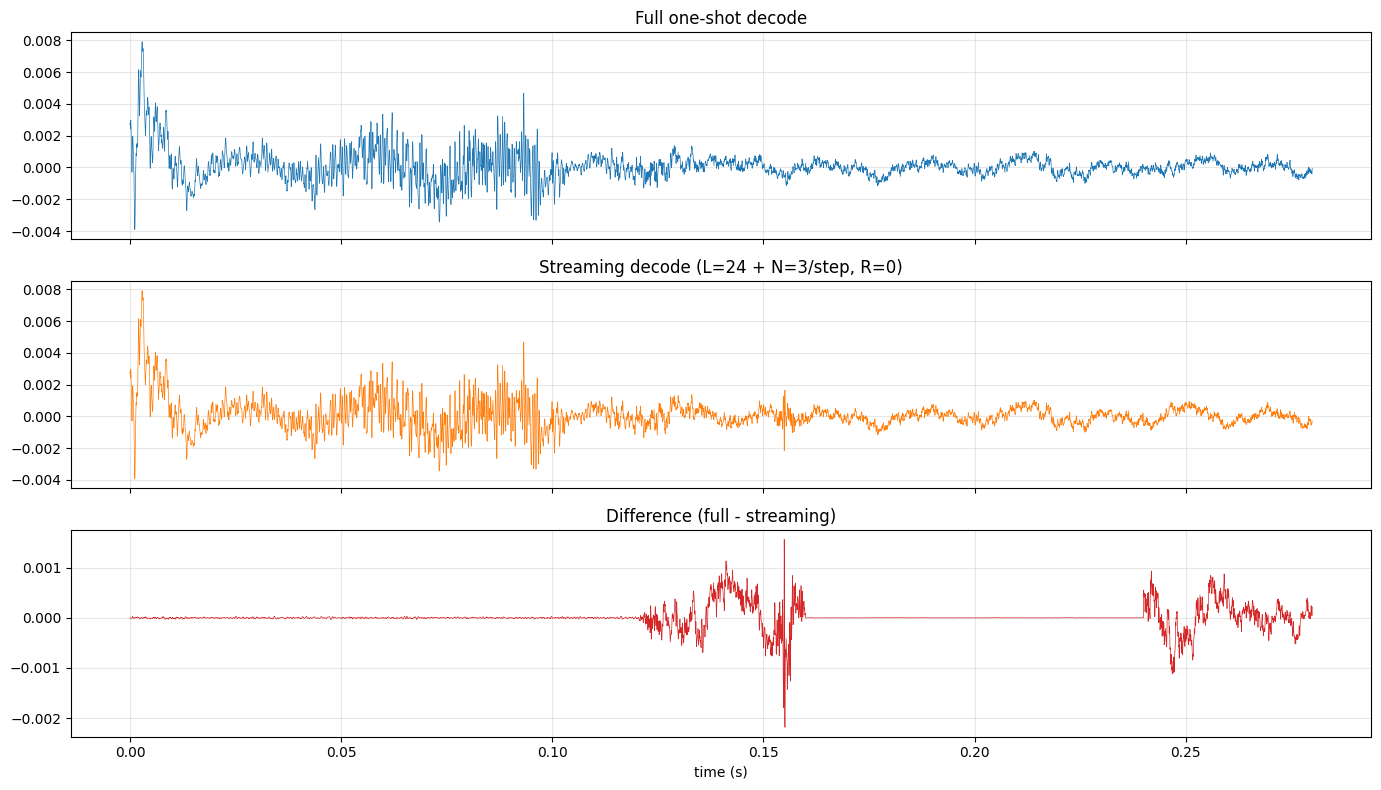

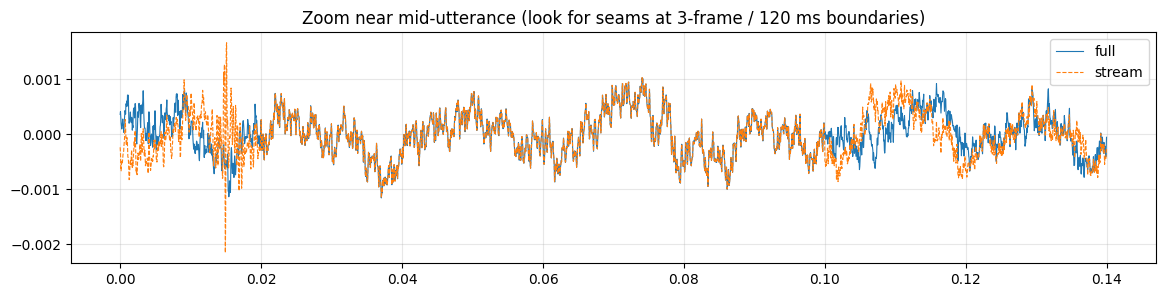

In [6]:
import matplotlib.pyplot as plt

n = min(len(full_wav), len(stream_wav))
a, b = full_wav[:n], stream_wav[:n]
diff = a - b
print(f"length: full={len(full_wav)}  stream={len(stream_wav)}  (compared first {n})")
print(f"max |diff| = {np.abs(diff).max():.3e}   RMS diff = {np.sqrt((diff**2).mean()):.3e}")
print(f"signal RMS = {np.sqrt((a**2).mean()):.3e}")

t = np.arange(n) / SR
fig, ax = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
ax[0].plot(t, a, lw=0.5)
ax[0].set_title("Full one-shot decode")
ax[1].plot(t, b, lw=0.5, color="tab:orange")
ax[1].set_title(f"Streaming decode (L={LEFT_CONTEXT} + N={CHUNK_FRAMES}/step, R={RIGHT_CONTEXT})")
ax[2].plot(t, diff, lw=0.5, color="tab:red")
ax[2].set_title("Difference (full - streaming)")
ax[2].set_xlabel("time (s)")
for a_ in ax:
    a_.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Zoom on a chunk boundary region (~middle) to inspect seams.
mid = n // 2
w = min(SR // 2, n - mid)
plt.figure(figsize=(14, 3))
plt.plot(np.arange(w) / SR, a[mid : mid + w], lw=0.8, label="full")
plt.plot(np.arange(w) / SR, b[mid : mid + w], lw=0.8, ls="--", label="stream")
plt.title("Zoom near mid-utterance (look for seams at 3-frame / 120 ms boundaries)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6. Listen

Play both and save them as wavs for offline comparison.

In [7]:
import soundfile as sf
from IPython.display import Audio, display

sf.write("decode_full.wav", full_wav, SR)
sf.write("decode_stream.wav", stream_wav, SR)
print("wrote decode_full.wav and decode_stream.wav")

print("Full one-shot decode:")
display(Audio(full_wav, rate=SR))
print("Streaming decode (24 ctx + 3/step):")
display(Audio(stream_wav, rate=SR))

wrote decode_full.wav and decode_stream.wav
Full one-shot decode:


Streaming decode (24 ctx + 3/step):
